# Phase 1 - Global Fuel Price Linear Regression

This notebook runs the Phase 1 pipeline for a scikit-learn linear regression model and exports a browser-ready JSON model for the static HTML/CSS/JS application.

In [2]:
import json
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()
if (current_dir / "pipeline.py").exists():
    sys.path.insert(0, str(current_dir))
elif (current_dir / "phase1" / "pipeline.py").exists():
    sys.path.insert(0, str(current_dir / "phase1"))

from pipeline import create_diagnostic_plots, run_analysis

In [3]:
result = run_analysis(create_plots=False)

df = result["df"]
working_df = result["working_df"]
metrics = result["metrics"]

print("Target:", result["target_column"])
print("Model export:", result["export_path"])
print("Metrics:", metrics)

Project dir: C:\Users\elias\Desktop\fuel-price-predictor\phase1
Data path   : C:\Users\elias\Desktop\fuel-price-predictor\phase1\global_fuel_prices_2020_2026.csv
Target      : petrol_usd_liter
Dropped     : ['date', 'diesel_usd_liter', 'lpg_usd_liter']
Rows used   : 27468
Numeric     : ['brent_crude_usd', 'tax_percentage', 'date_year', 'date_month', 'date_weekofyear']
Categorical : ['country', 'region', 'income_level', 'subsidy_level']
MAE         : 0.1677
RMSE        : 0.2600
R2          : 0.9724
Saved model : C:\Users\elias\Desktop\fuel-price-predictor\phase1\docs\model.json
Target: petrol_usd_liter
Model export: C:\Users\elias\Desktop\fuel-price-predictor\phase1\docs\model.json
Metrics: {'mae': 0.16771550888537107, 'rmse': 0.2599724557039657, 'r2': 0.9724231924627404}


## Dataset preview

In [5]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [6]:
print("Rows used:", len(working_df))
print("Dropped columns:", result["columns_to_drop"])
print("Numeric features:", result["numeric_features"])
print("Categorical features:", result["categorical_features"])

Rows used: 27468
Dropped columns: ['date', 'diesel_usd_liter', 'lpg_usd_liter']
Numeric features: ['brent_crude_usd', 'tax_percentage', 'date_year', 'date_month', 'date_weekofyear']
Categorical features: ['country', 'region', 'income_level', 'subsidy_level']


## Diagnostic plots

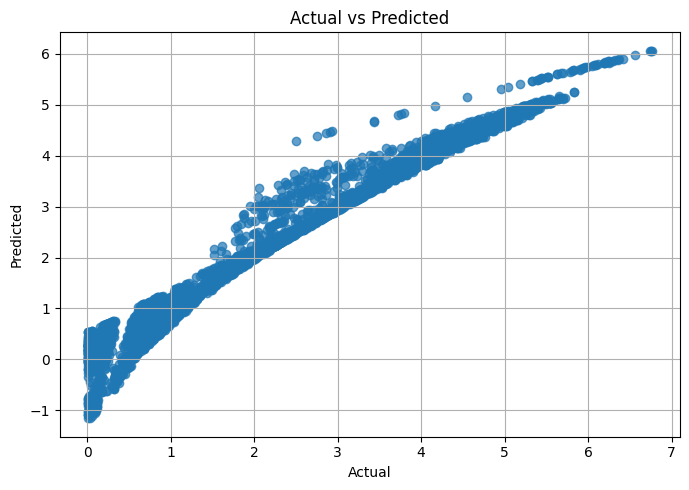

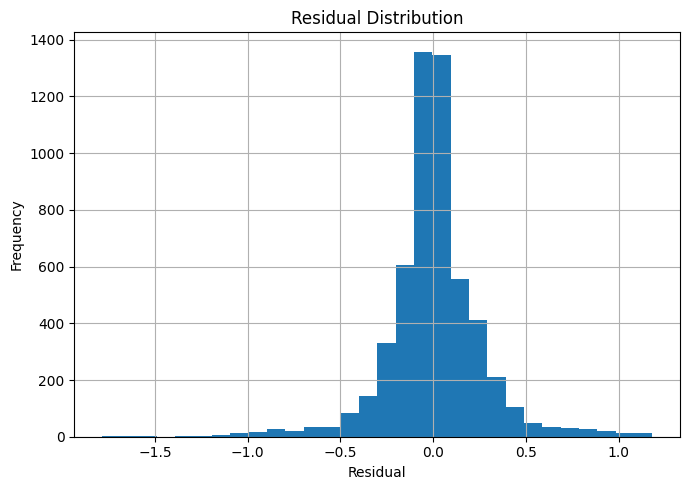

In [8]:
create_diagnostic_plots(result)

## Export verification

In [10]:
with open(result["export_path"], "r", encoding="utf-8") as file:
    exported = json.load(file)

print(exported["modelName"])
print(exported["targetColumn"])
print(exported["metrics"])
print("Numeric features:", [entry["name"] for entry in exported["numericFeatures"]])
print("Categorical features:", [entry["name"] for entry in exported["categoricalFeatures"]])

Global Fuel Price Linear Regression
petrol_usd_liter
{'mae': 0.16771550888537107, 'rmse': 0.2599724557039657, 'r2': 0.9724231924627404}
Numeric features: ['brent_crude_usd', 'tax_percentage', 'date_year', 'date_month', 'date_weekofyear']
Categorical features: ['country', 'region', 'income_level', 'subsidy_level']
